# (17) poisson conditional

**Motivation**: host = ```mach```, device = ```cuda:2``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.fighelper import *
from vae.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from analysis.chosen import *
from figures.analysis import *
from figures.imgs import plot_weights

device_idx = 2
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:2  ———  host: mach

## vH16

Intermediate beta: $(T, \beta) = (8, 1.0)$

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('vH16', model_type, 'jacob|lin')

cfg_vae['track_stats'] = True

seq_len = 8
cfg_vae['seq_len'] = seq_len
cfg_vae['clamp_du'] = 5
cfg_vae['clamp_u'] = 5
cfg_vae['init_scale'] = 0.001

cfg_tr['grad_clip'] = 5000
cfg_tr['kl_beta'] = 1/8 * seq_len
cfg_tr['lr'] = 1e-4

cfg_tr['file_name'] = 'patches_quantized.npy'

In [4]:
vae = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = TrainerVAE(vae, ConfigTrainVAE(**cfg_tr), device=device)
print_num_params(vae.layer)

print(f"{vae.cfg.name()}\n{tr.cfg.name()}_({vae.timestamp})\n")
tr.n_iters

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  132.1 K   |
|     ———      |    ———     |
|     phi      |  131.1 K   |
+--------------+------------+

poisson_vH16_t-8_z-[512]_<jacob|lin>
b200-ep300-lr(0.0001)_beta(1:0x0.1)_temp(0.05:lin-0.5)_gr(5000)_(2024_10_17,19:05)

297900

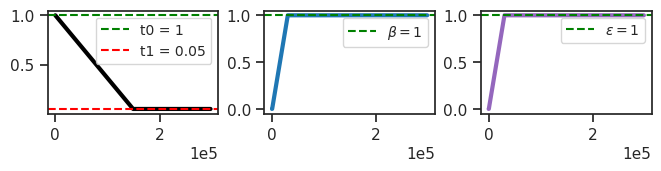

In [5]:
tr.show_schedules();

In [6]:
x = tr.dl_vld.dataset.tensors[0]
x.min(), x.max()

(tensor(3., device='cuda:2'), tensor(255., device='cuda:2'))

In [7]:
tr.train()

epoch # 300, avg loss: 25771.711862: 100%|██| 300/300 [5:47:55<00:00, 69.59s/it]


### Load

In [ ]:
tr, meta = load_model(
    'poisson_vH16_t-8_z-[512]_<jacob|lin>',
    'b200-ep300-lr(0.002)_beta(3:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2024_10_17,14:17)',
    device=device,
)
meta['checkpoint']

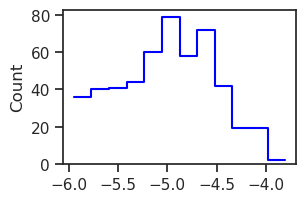

In [8]:
log_rate = tonp(tr.model.layer.log_rate.squeeze())
histplot(log_rate, color='b');

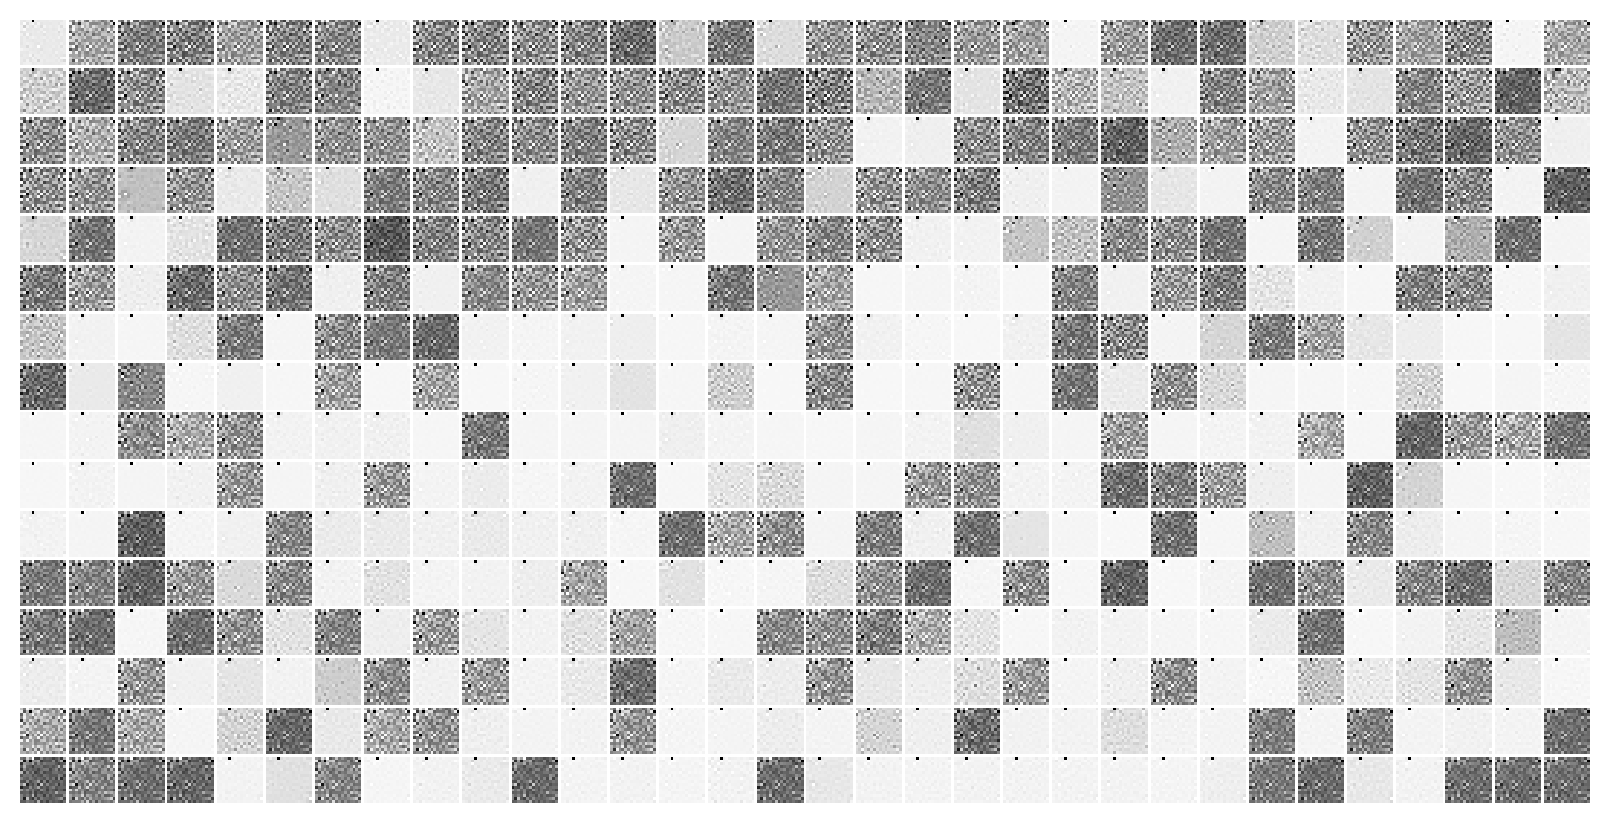

In [9]:
_ = tr.model.show('phi', order=np.argsort(log_rate))

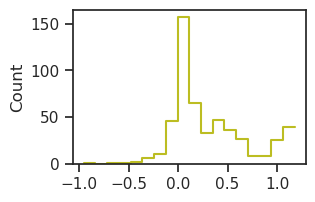

In [10]:
bias = tonp(tr.model.layer.bias.squeeze())
histplot(bias, color='C8');

100%|███████████████████████████████████| 2/2 [00:10<00:00,  5.31s/it]


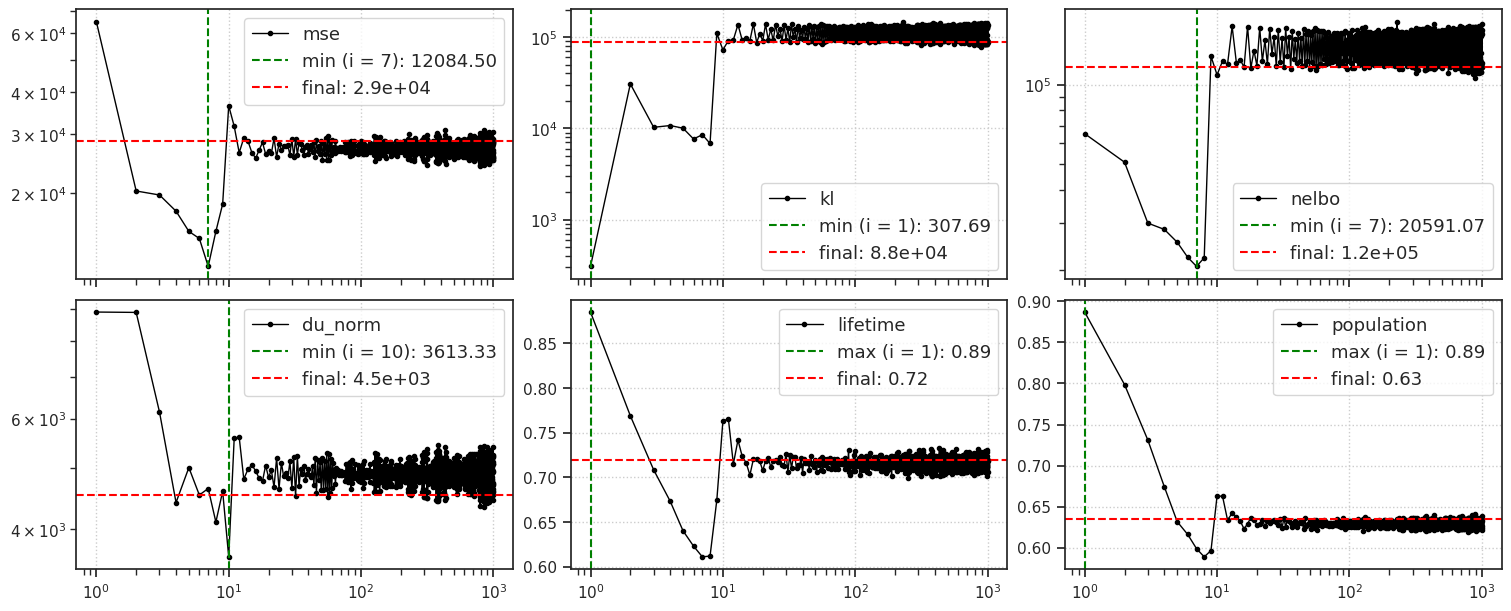

CPU times: user 13.1 s, sys: 684 ms, total: 13.7 s
Wall time: 13.7 s


In [11]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis(**kws)

_ = plot_convergence(results, color='k')

In [12]:
x = next(iter(tr.dl_vld))[0]
x.shape

torch.Size([200, 1, 16, 16])

In [13]:
output = tr.model.xtract_ftr(
    x=x,
    seq=range(24),
    return_extras=True,
).stack()

In [14]:
list(output)

['loss_kl',
 'loss_recon',
 'posterior',
 'ff',
 'recon',
 'state',
 'samples',
 'conditional']

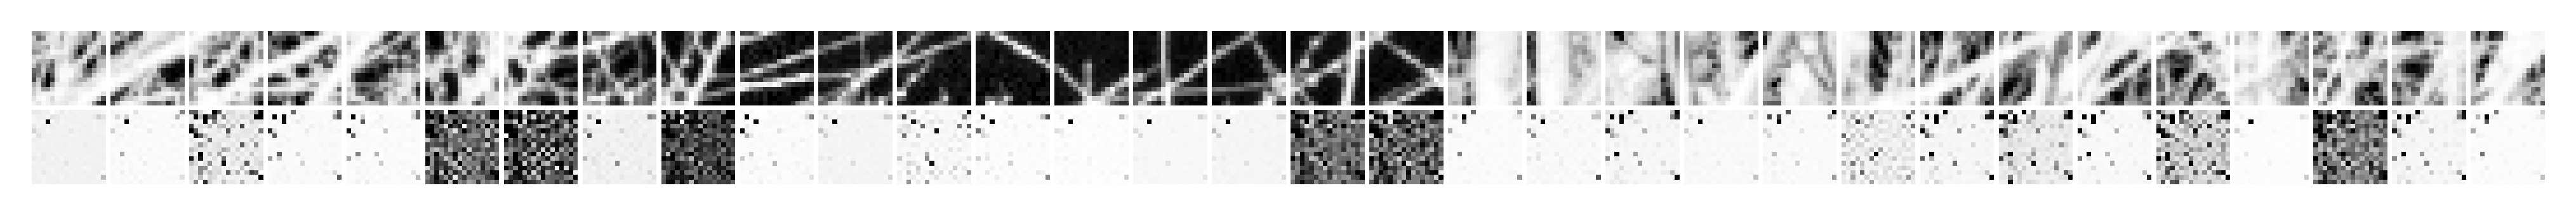

In [15]:
num = 32

x2p = torch.cat([
    tr.dl_vld.dataset.tensors[0][:num],
    output['recon'][:num, -1].reshape(tr.model.cfg.shape),
])
_ = plot_weights(x2p, nrows=2, cmap='Greys', dpi=500)

In [18]:
d = output['conditional']['23']

In [27]:
mse = (x.flatten(start_dim=1) - d.loc) ** 2
mse = torch.sum(mse, dim=1)
mse.mean()

tensor(30.9770, device='cuda:0')

In [30]:
recon_loss = d.log_prob(x.flatten(start_dim=1)).mul(-1.0)
recon_loss = torch.sum(recon_loss, dim=1)
recon_loss.mean()

tensor(121.9001, device='cuda:0')

In [42]:
def compute_log_p_x_z(d, x):
    mu, sd = d.loc, d.scale
    zeta = (x - mu) / sd
    nll = 0.5 * zeta ** 2 + torch.log(sd) + 0.5 * np.log(2 * np.pi)
    return nll

In [43]:
recon_loss = compute_log_p_x_z(d, x.flatten(start_dim=1))
recon_loss = torch.sum(recon_loss, dim=1)
recon_loss.mean()

tensor(121.9001, device='cuda:0')

In [48]:
divide_integer(1024, (0.5, 0.5))

[512, 512]